# Assignment 4: Customer Segmentation with Clustering

**Student Name:** Anthony Mollica

**Date:** 2/16/2026

---

## Assignment Overview

You've been hired as a data science consultant by a UK-based online gift retailer. They're spending the same amount on marketing to all customers regardless of value. Your task: segment their customer base using transaction data from 2009-2011, identify distinct customer groups, and provide actionable recommendations for each segment.

---

## Step 1: Import Libraries and Load Data

In [47]:
pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [49]:
# Load the Online Retail II dataset
# TODO: Load online_retail_II.csv from the data folder
df = pd.read_csv('data\online_retail_II.csv')
print("✓ Dataset loaded successfully")

# Display basic information
# TODO: Display the first few rows and basic info about the dataset

print("\nFirst few rows:")
print(df.head())

print("\nDataset info:")
df.info()
print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Dataset shape: {df.shape if df is not None else 'Not loaded'}")
print(f"Date range: [Check InvoiceDate column]")
print("="*80)

<>:3: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:3: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\aj4ho\AppData\Local\Temp\ipykernel_24644\3418043073.py:3: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  df = pd.read_csv('data\online_retail_II.csv')


✓ Dataset loaded successfully

First few rows:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  -

---
## Step 2: Aggregate Transaction Data to Customer-Level RFM Features

### Clean Transaction Data

Before aggregating to customer-level, clean the transaction data:
- Remove rows with missing Customer ID
- Remove returns (negative Quantity)
- Create TotalSpend column (Quantity × Price)
- Convert InvoiceDate to datetime

In [50]:
# Clean the data
# TODO: Remove missing Customer IDs
df = df.dropna(subset=['Customer ID'])

# TODO: Remove negative quantities (returns)
df = df[df['Quantity'] > 0]

# TODO: Create TotalSpend column
df['TotalSpend'] = df['Quantity'] * df['Price']

# TODO: Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


print("\n" + "="*80)
print("CHECKPOINT: After data cleaning")
print(f"Remaining transactions: {len(df) if df is not None else 'N/A'}")
print(f"Unique customers: {df['Customer ID'].nunique() if df is not None else 'N/A'}")
print("="*80)


CHECKPOINT: After data cleaning
Remaining transactions: 805620
Unique customers: 5881


### Calculate RFM Features for Each Customer

Create three features for each customer:
- **Recency**: Days since last purchase (use December 10, 2011 as reference date)
- **Frequency**: Total number of unique invoices
- **Monetary**: Total amount spent

In [51]:
# Set reference date for recency calculation
reference_date = pd.to_datetime('2011-12-10')

# Calculate RFM metrics for each customer
rfm_df = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                      # Frequency
    'TotalSpend': 'sum'                                        # Monetary
}).reset_index()

# Rename columns for clarity
rfm_df.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',  # fixed from 'InvoiceNo'
    'TotalSpend': 'Monetary'
}, inplace=True)

# Display checkpoint info
print("\n" + "="*80)
print("CHECKPOINT: RFM Features Created")
if rfm_df is not None:
    print(f"Number of customers: {len(rfm_df)}")
    print(f"\nRFM Summary Statistics:")
    print(rfm_df.describe())
print("="*80)



CHECKPOINT: RFM Features Created
Number of customers: 5881

RFM Summary Statistics:
        Customer ID      Recency    Frequency       Monetary
count   5881.000000  5881.000000  5881.000000    5881.000000
mean   15314.674205   200.992858     6.287196    3017.076888
std     1715.429759   209.489651    13.012879   14734.128619
min    12346.000000     0.000000     1.000000       0.000000
25%    13833.000000    25.000000     1.000000     347.800000
50%    15313.000000    95.000000     3.000000     897.620000
75%    16797.000000   379.000000     7.000000    2304.180000
max    18287.000000   738.000000   398.000000  608821.650000


---
## Step 3: Standardize Features and Determine Optimal k

### Standardize RFM Features

K-means is sensitive to feature scale, so standardize features to mean=0, std=1

In [52]:
# TODO: Use StandardScaler to standardize Recency, Frequency, and Monetary
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary']])
print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
if rfm_scaled is not None:
    print(f"Scaled features shape: {rfm_scaled.shape}")
    print(f"Mean of scaled features: {rfm_scaled.mean(axis=0)}")
    print(f"Std of scaled features: {rfm_scaled.std(axis=0)}")
print("="*80)


CHECKPOINT: Features Standardized
Scaled features shape: (5881, 3)
Mean of scaled features: [ 9.18232408e-17 -2.77886123e-17  2.41640107e-18]
Std of scaled features: [1. 1. 1.]


### Elbow Method: Test k from 2 to 10

Calculate inertia (within-cluster sum of squares) for different values of k

In [53]:
# TODO: Test k values from 2 to 10
# For each k:
#   - Train KMeans(n_clusters=k, random_state=42)
#   - Store inertia value'
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)

# Your code here
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)


print("\n" + "="*80)
print("CHECKPOINT: Elbow Method Calculated")
print(f"Tested k values: {list(k_range)}")
print("="*80)


CHECKPOINT: Elbow Method Calculated
Tested k values: [2, 3, 4, 5, 6, 7, 8, 9, 10]


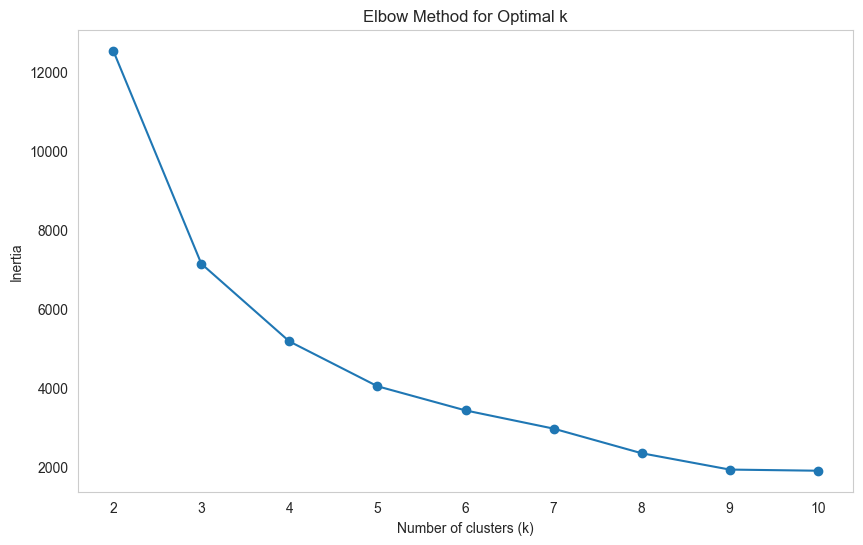

In [54]:
# TODO: Plot the elbow curve
# x-axis: k values
# y-axis: inertia
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid()
plt.show()

### Silhouette Score Analysis

Calculate silhouette scores to validate cluster quality

In [55]:
# TODO: Calculate silhouette scores for k from 2 to 10
# For each k:
#   - Train KMeans
#   - Calculate silhouette_score(rfm_scaled, labels)

silhouette_scores = []

# Your code here
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

print("\n" + "="*80)
print("CHECKPOINT: Silhouette Scores Calculated")
print("="*80)


CHECKPOINT: Silhouette Scores Calculated


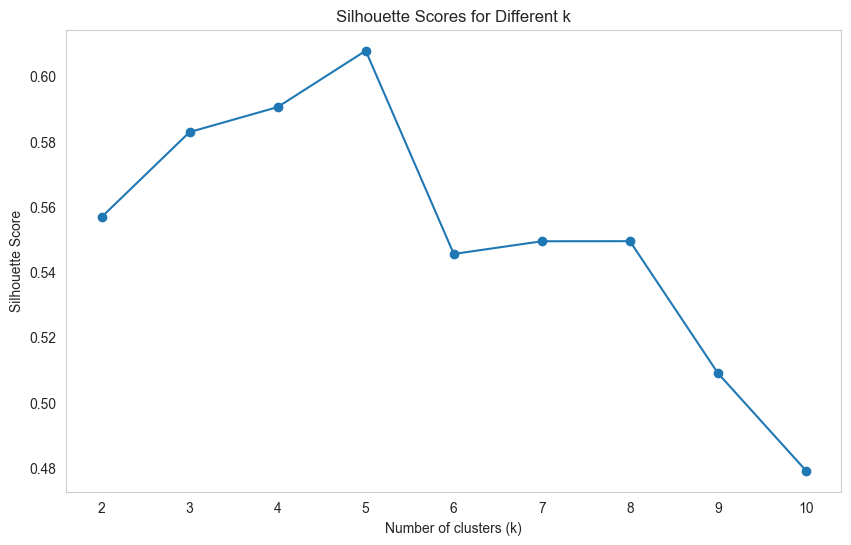

In [56]:
# TODO: Plot silhouette scores
# x-axis: k values
# y-axis: silhouette score
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid()
plt.show()

### Select Optimal k

**Your k selection justification (write 2-3 sentences):**
Based on the elbow plot, the curve begins to level off around k = 5, indicating reductions in inertia beyond that point. Additionally, the silhouette score reaches its highest value at k = 5 (around 0.61), suggesting the clusters are well-separated and cohesive. So, k = 5 provides the best balance between minimizing inertia and maximizing cluster quality.


In [57]:
# TODO: Set your chosen k value
optimal_k = 5  # Replace with your chosen k (e.g., 4, 5, or 6)

print(f"Chosen k value: {optimal_k}")

Chosen k value: 5


---
## Step 4: Train K-Means Model and Visualize Segments

### Train Final K-Means Model

In [58]:
# TODO: Train KMeans with your optimal_k and random_state=42
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(rfm_scaled)

# TODO: Add cluster labels to rfm_df
rfm_df['Cluster'] = kmeans.labels_


print("\n" + "="*80)
print("CHECKPOINT: K-Means Model Trained")
print(f"Number of clusters: {optimal_k}")
if 'Cluster' in rfm_df.columns:
    print(f"\nCluster sizes:")
    print(rfm_df['Cluster'].value_counts().sort_index())
print("="*80)


CHECKPOINT: K-Means Model Trained
Number of clusters: 5

Cluster sizes:
Cluster
0    3619
1    1929
2      17
3       2
4     314
Name: count, dtype: int64


### Visualize Customer Segments

Create a 2D scatter plot showing Frequency vs Monetary, colored by cluster

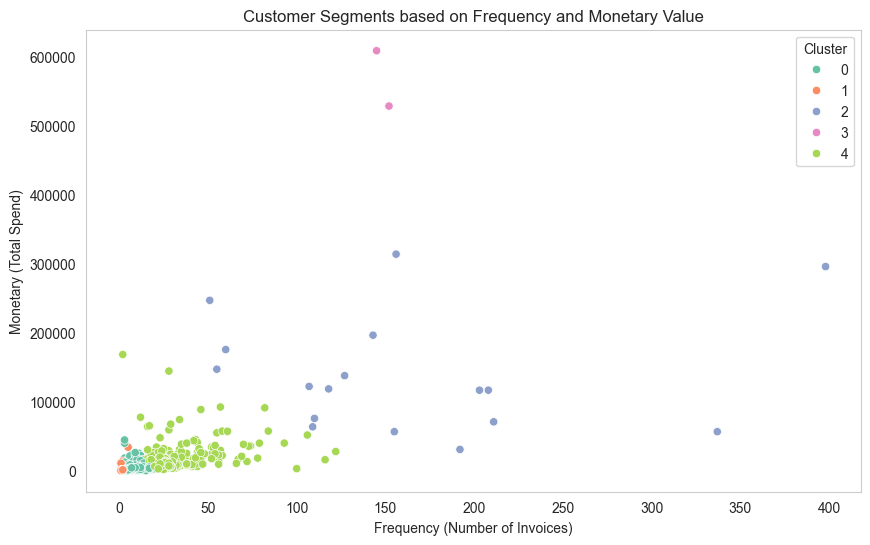

In [60]:
# TODO: Create scatter plot
# x-axis: Frequency
# y-axis: Monetary
# color: Cluster
# Include legend
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm_df, x='Frequency', y='Monetary', hue='Cluster', palette='Set2')
plt.title('Customer Segments based on Frequency and Monetary Value')
plt.xlabel('Frequency (Number of Invoices)')
plt.ylabel('Monetary (Total Spend)')
plt.legend(title='Cluster')
plt.grid()
plt.show()  


### Calculate Cluster Centers

Show the mean RFM values for each cluster

In [63]:
# Calculate mean Recency, Frequency, and Monetary for each cluster
cluster_summary = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print("\n" + "="*80)
print("CLUSTER CENTERS (Mean RFM Values)")
print("="*80)

# Display cluster summary
print(cluster_summary)

print("="*80)



CLUSTER CENTERS (Mean RFM Values)
            Recency   Frequency       Monetary
Cluster                                       
0         73.795800    5.406190    2036.538555
1        469.925350    2.159150     752.396388
2         27.235294  161.176471  137806.995294
3          0.500000  148.500000  568712.085000
4         25.547771   32.509554   17330.192430


---
## Step 5: Interpret Segments and Provide Business Recommendations

### Segment 0: [Occasional Shoppers]

**Customer Profile (3-5 sentences):**

Segment 0 consists of moderate-value customers with an average recency of about 74 days, a low purchase frequency of roughly 5 transactions, and average spending of around $2,037. Their purchasing behavior suggests occasional engagement rather than strong loyalty, as they do not buy frequently or spend at high levels. This segment represents customers who may be at risk of churn but could potentially be reactivated through targeted promotions or engagement strategies.

In [ ]:
# TODO: Calculate detailed statistics for Segment 0
# Show mean, median, min, max for R, F, M
# Filter Segment 0
segment_0 = rfm_df[rfm_df['Cluster'] == 0]

# Calculate detailed statistics (mean, median, min, max)
segment_0_stats = segment_0[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median', 'min', 'max'])

print("\n" + "="*80)
print("SEGMENT 0 - Occasional Shoppers")
print("="*80)
print(segment_0_stats.round(2))
print("="*80)



SEGMENT 0 - DETAILED RFM STATISTICS
        Recency  Frequency  Monetary
mean       73.8       5.41   2036.54
median     46.0       4.00   1180.23
min         0.0       1.00      0.00
max       283.0      21.00  44534.30


### Segment 1: [Inactive Customers]

**Customer Profile (3-5 sentences):**
Segment 1 consists of inactive or lost customers, with extremely high recency (around 470 days), very low purchase frequency, and low monetary value. Their long gap since the last purchase indicates disengagement and a high likelihood of churn. This segment represents low current business value and would require strong reactivation incentives to regain engagement.

In [ ]:
# TODO: Calculate detailed statistics for Segment 1
# Show mean, median, min, max for R, F, M
# Filter Segment 1
segment_1 = rfm_df[rfm_df['Cluster'] == 1]

# Calculate detailed statistics (mean, median, min, max)
segment_1_stats = segment_1[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median', 'min', 'max'])

print("\n" + "="*80)
print("SEGMENT 1 - Inactive Customers")
print("="*80)
print(segment_1_stats.round(2))
print("="*80)


SEGMENT 1 - DETAILED RFM STATISTICS
        Recency  Frequency  Monetary
mean     469.93       2.16    752.40
median   434.00       1.00    376.92
min      266.00       1.00      0.00
max      738.00      29.00  34095.26


### Segment 2: [Loyal Customers]

**Customer Profile (3-5 sentences):**
Segment 2 represents highly loyal and valuable customers, with very recent purchases, extremely high frequency, and strong monetary value. Their consistent and frequent buying behavior indicates strong engagement and long-term loyalty. This segment contributes significantly to overall revenue and should be prioritized for retention and relationship-building strategies.

In [ ]:
# TODO: Calculate detailed statistics for Segment 2
# Show mean, median, min, max for R, F, M
# Filter Segment 2
segment_2 = rfm_df[rfm_df['Cluster'] == 2]

# Calculate detailed statistics (mean, median, min, max)
segment_2_stats = segment_2[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median', 'min', 'max'])

print("\n" + "="*80)
print("SEGMENT 2 - Loyal Customers")
print("="*80)
print(segment_2_stats.round(2))
print("="*80)


SEGMENT 2 - DETAILED RFM STATISTICS
        Recency  Frequency   Monetary
mean      27.24     161.18  137807.00
median     2.00     143.00  118628.08
min        0.00      51.00   30861.06
max      372.00     398.00  313946.37


### [Continue for remaining segments]

[Add sections for Segment 3, 4, etc. depending on your chosen k]

### Segment 3: [Elite Customers]

Segment 3 is the most valuable customer group, with extremely recent purchases, very high purchase frequency, and the highest overall monetary value. Their buying behavior shows strong loyalty, heavy engagement, and large transaction volumes. This segment represents elite VIP customers who drive a substantial portion of total revenue and should be a top priority for retention efforts.

In [ ]:
segment_3 = rfm_df[rfm_df['Cluster'] == 3]

# Calculate detailed statistics (mean, median, min, max)
segment_3_stats = segment_3[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median', 'min', 'max'])

print("\n" + "="*80)
print("SEGMENT 3 - Elite Customers")
print("="*80)
print(segment_3_stats.round(2))
print("="*80)


SEGMENT 3 - DETAILED RFM STATISTICS
        Recency  Frequency   Monetary
mean        0.5      148.5  568712.08
median      0.5      148.5  568712.08
min         0.0      145.0  528602.52
max         1.0      152.0  608821.65


### Segment 4: [Mid-Tier Customers]

Segment 4 consists of strong mid-tier customers with fairly recent purchases, moderate-to-high frequency, and solid monetary value. They demonstrate consistent buying behavior but at lower levels than the elite segments. This group represents dependable revenue with strong potential for upselling and long-term growth through targeted engagement strategies.

In [69]:
segment_4 = rfm_df[rfm_df['Cluster'] == 4]

# Calculate detailed statistics (mean, median, min, max)
segment_4_stats = segment_4[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median', 'min', 'max'])

print("\n" + "="*80)
print("SEGMENT 4 - Mid-Tier Customers")
print("="*80)
print(segment_4_stats.round(2))
print("="*80)


SEGMENT 4 - Mid-Tier Customers
        Recency  Frequency   Monetary
mean      25.55      32.51   17330.19
median     8.50      28.00   12136.33
min        0.00       2.00    1820.44
max      497.00     122.00  168472.50


---
## Business Recommendations

### Recommendation 1: [Reward VIP Customers]

**Which segment(s) does this target?** [Elite Customers (Segment 3)]

**Recommendation (3-5 sentences):**

For the Elite Customers, the company should implement a loyalty and rewards program that recognizes their frequent purchases and high spending. Personalized offers, early access to new products, or exclusive events can be delivered via email, mobile app notifications, or direct account managers to reinforce engagement. This strategy will strengthen their loyalty, increase repeat purchases, and maintain their high revenue contribution. By making these customers feel valued and appreciated, the company reduces the risk of churn and encourages continued high-value transactions.

### Recommendation 2: [Re-engage Customers]

**Which segment(s) does this target?** [Occasional Shoppers (Segment 0)]

**Recommendation (3-5 sentences):**

For Occasional Buyers, the company should focus on re-engagement campaigns to encourage more frequent purchases. Targeted email promotions, personalized discounts, or limited-time offers can be used to incentivize them to return. Highlighting new products or reminding them of past favorites can also rekindle interest. This approach works because these customers have shown some prior engagement but are at risk of drifting away, so timely and relevant messaging can convert them into more consistent buyers.

### Recommendation 3: [Title]

**Which segment(s) does this target?** [Inactive Customers(Segment 1)]

**Recommendation (3-5 sentences):**

For Inactive Customers, the company should implement a targeted reactivation strategy using special incentives, such as “we miss you” discounts, bundled offers, or personalized product recommendations. Channels like email campaigns, retargeting ads, or even SMS notifications can be effective to capture their attention. Messaging should focus on urgency, value, and reminders of previous positive experiences with the brand. This approach is likely to succeed because these customers have purchased in the past, and a well-timed incentive can motivate them to return. Even partial reactivation can help recover lost revenue at a low acquisition cost.

---
## Step 6: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - RFM features properly calculated
   - Elbow method and silhouette score visualizations
   - Written justification for your k selection
   - Customer segment scatter plot
   - Descriptive names and profiles for each segment
   - Three specific business recommendations
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed customer segmentation assignment'
git push
```

Submit your GitHub repository link on the course platform.